In [2]:
import cv2
import cv2.aruco as aruco

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)
parameters = aruco.DetectorParameters()

cap = cv2.VideoCapture(0,cv2.CAP_DSHOW)

while True:
    ret, frame = cap.read()
    if not ret: break

    corners, ids, rejected = aruco.detectMarkers(frame, aruco_dict, parameters=parameters)

    if ids is not None:
        aruco.drawDetectedMarkers(frame, corners, ids)
        for i in range(len(ids)):
            print(f"Detected Marker ID: {ids[i][0]}")
    
    cv2.imshow("ArUco Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


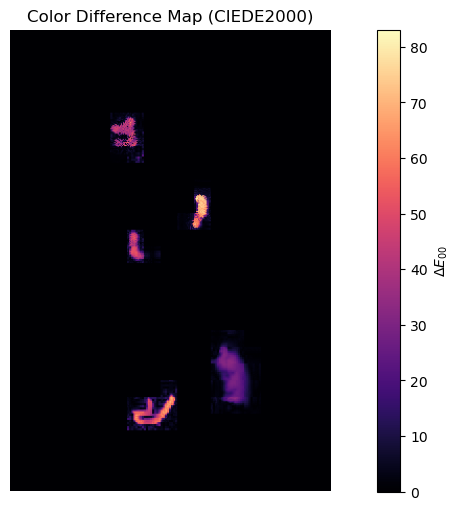

In [4]:
import colour
import numpy as np
import matplotlib.pyplot as plt
from PIL  import Image

img1 = np.array(Image.open('Rose1.png').convert('RGB')).astype(float) / 255.0
img2 = np.array(Image.open('Rose2.png').convert('RGB')).astype(float) / 255.0

def rgb_to_lab(rgb_array):
    xyz = colour.sRGB_to_XYZ(rgb_array)
    lab = colour.XYZ_to_Lab(xyz)
    return lab

img1_lab = rgb_to_lab(img1)
img2_lab = rgb_to_lab(img2)

delta_e_map = colour.delta_E(img1_lab, img2_lab, method='CIE2000')

plt.figure(figsize=(12, 6))
plt.imshow(delta_e_map, cmap='magma')
plt.colorbar(label=r'$\Delta E_{00}$')
plt.title('Color Difference Map (CIEDE2000)')
plt.axis('off')
plt.show()

In [2]:
import cv2
import numpy as np
import colour

def extract_average_color(image, x, y, width, height):
    """
    Crops a region from the image and returns the median RGB color.
    Using median ignores shadows, reflections, or text inside the patch.
    """
    # Crop the region of interest (ROI)
    roi = image[y:y+height, x:x+width]
    
    # Calculate the median color across the cropped area
    # Note: OpenCV loads images in BGR, so we convert to RGB
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    median_rgb = np.median(roi_rgb, axis=(0, 1))
    
    return median_rgb

def rgb_to_lab(rgb_array):
    """Converts a 0-255 RGB array to CIE Lab color space."""
    # Normalize RGB to 0.0 - 1.0 range for colour-science
    rgb_normalized = np.array(rgb_array) / 255.0
    xyz = colour.sRGB_to_XYZ(rgb_normalized)
    lab = colour.XYZ_to_Lab(xyz)
    return lab

def diagnose_pad(test_pad_rgb, reference_colors):
    """
    Takes the RGB color of a test pad and a dictionary of reference colors,
    and returns the label of the closest match.
    """
    test_lab = rgb_to_lab(test_pad_rgb)
    
    best_match = None
    smallest_delta_e = float('inf')
    
    for label, ref_rgb in reference_colors.items():
        ref_lab = rgb_to_lab(ref_rgb)
        
        # Calculate color difference using CIEDE2000
        delta_e = colour.delta_E(test_lab, ref_lab, method='CIE2000')
        
        if delta_e < smallest_delta_e:
            smallest_delta_e = delta_e
            best_match = label
            
    return best_match

# ==========================================
# EXAMPLE USAGE
# ==========================================

# 1. Let's pretend you used OpenCV to extract the color of the Glucose pad from the strip
mock_extracted_strip_color = [140, 180, 130] # A greenish color

# 2. You build a dictionary of the known reference colors for Glucose
# (You would normally extract these from the chart image automatically)
glucose_references = {
    "Negative":[140, 208, 206],
    "Trace (5)":[168, 200, 145],
    "Small (15)":[143, 178, 112],
    "Moderate (30)":[128, 140, 56],
    "Large (60)": [156, 114, 46],
    "Very Large (110)": [108, 64, 28]
}

# 3. Run the diagnosis
result = diagnose_pad(mock_extracted_strip_color, glucose_references)

print(f"The closest match for the Glucose test is: {result}")

The closest match for the Glucose test is: Small (15)


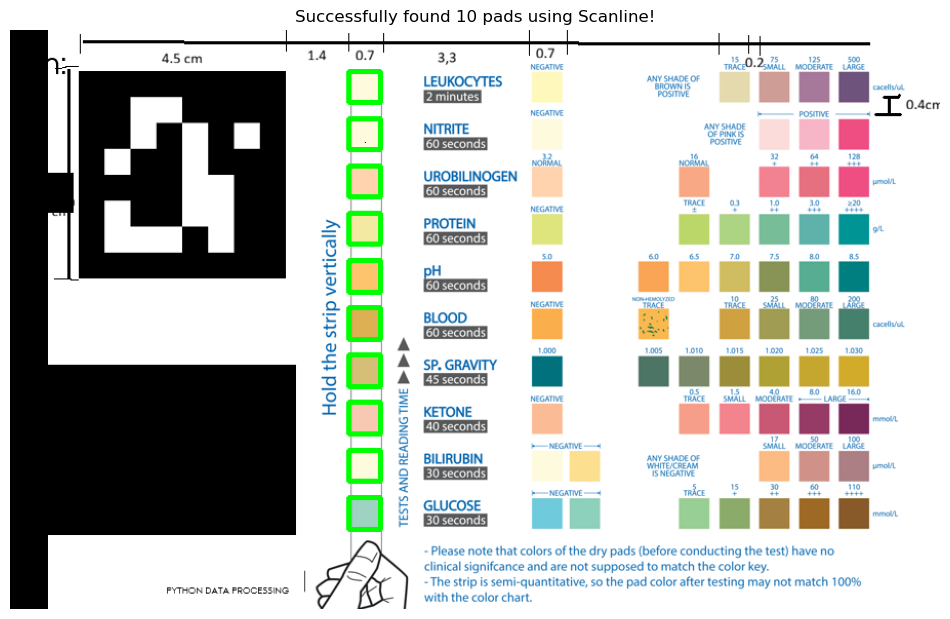

--- Extracted Pad Colors (RGB) ---
Leukocytes.....: [253 250 222]
Nitrite........: [253 250 222]
Urobilinogen...: [254 211 174]
Protein........: [243 233 163]
pH.............: [253 195 109]
Blood..........: [220 176  83]
Sp. Gravity....: [213 191 119]
Ketone.........: [248 201 178]
Bilirubin......: [253 250 222]
Glucose........: [158 210 193]


In [5]:
import cv2
import cv2.aruco as aruco
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the CLEAN original image
image_path = 'peestick.png'
frame = cv2.imread(image_path)
frame_rgb = cv2.cvtColor(frame.copy(), cv2.COLOR_BGR2RGB) # Convert to use camera instead of image on PC

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)
parameters = aruco.DetectorParameters()
corners, ids, rejected = aruco.detectMarkers(frame, aruco_dict, parameters=parameters)

extracted_colours = []

if ids is not None:
    # 2. Map coordinates & Scale
    top_left = corners[0][0][0]
    top_right = corners[0][0][1]
    bottom_right = corners[0][0][2]
    
    marker_pixel_width = np.linalg.norm(top_left - top_right)
    pixels_per_cm = marker_pixel_width / 4.5
    
    marker_right_x = int((top_right[0] + bottom_right[0]) / 2)
    marker_top_y = int(top_right[1])
    
    strip_left_x = int(marker_right_x + (1.4 * pixels_per_cm))
    strip_right_x = int(strip_left_x + (0.7 * pixels_per_cm))
    
    # Get the exact X-coordinate for the dead-center of the strip
    center_x = int((strip_left_x + strip_right_x) / 2)
    
    # We take a 5-pixel wide column down the center to average out any image noise
    scan_column = frame[marker_top_y : , center_x-2 : center_x+3]
    
    # Calculate the average [B, G, R] color at every Y-coordinate
    scanline_bgr = np.mean(scan_column, axis=1)
    
    # Calculate how far away each pixel's color is from pure white[255, 255, 255]
    diff_from_white = np.sum(np.abs(scanline_bgr - [255, 255, 255]), axis=1)
    
    # A pixel belongs to a pad if it is noticeably different from white (threshold > 15)
    is_pad_pixel = diff_from_white > 15
    
    pad_regions = []
    in_pad = False
    start_y = 0
    
    # Loop down the boolean array to find the start and end of every colored block
    for y, pad_val in enumerate(is_pad_pixel):
        if pad_val and not in_pad:
            in_pad = True
            start_y = y
        elif not pad_val and in_pad:
            in_pad = False
            end_y = y
            # Filter out tiny specks (must be taller than 15 pixels)
            if (end_y - start_y) > 15:
                pad_regions.append((start_y + marker_top_y, end_y + marker_top_y))
    
    # We only care about the first 10 pads (this automatically ignores the hand holding the stick at the bottom)
    pad_regions = pad_regions[:10]
    
    extracted_colors =[]
    
    for i, (y1, y2) in enumerate(pad_regions):
        pad_h = y2 - y1
        center_y = y1 + (pad_h // 2)
        
        # Extract color strictly from the center point
        # Using frame_rgb so the color order is correct[R, G, B]
        rgb_color = frame_rgb[center_y, center_x]
        extracted_colors.append(rgb_color)
        
        # Draw the bounding box and center dot
        cv2.rectangle(frame_rgb, (strip_left_x, y1), (strip_right_x, y2), (0, 255, 0), 3)


    # 3. Display the result
    plt.figure(figsize=(12, 16))
    plt.imshow(frame_rgb)
    plt.title(f'Successfully found {len(extracted_colors)} pads using Scanline!')
    plt.axis('off')
    plt.show()
    
    # Print the colors
    print("--- Extracted Pad Colors (RGB) ---")
    pad_names =["Leukocytes", "Nitrite", "Urobilinogen", "Protein", "pH", 
                 "Blood", "Sp. Gravity", "Ketone", "Bilirubin", "Glucose"]
                 
    for i, color in enumerate(extracted_colors):
        name = pad_names[i] if i < len(pad_names) else f"Unknown Pad {i+1}"
        print(f"{name:.<15}: {color}")

else:
    print("Could not detect any ArUco markers in the image.")

In [10]:
reference_chart = {
    "Leukocytes": {
        "Negative": [254, 248, 188],
        "15 - Trace": [229, 218, 174],
        "75 - Small": [206, 157, 149],
        "125 - Moderate": [166, 120, 153],
        "500 - Large": [110, 83, 124]
    },
    "Nitrite": {
        "Negative": [253, 250, 222],
        "Positive (+)": [251, 220, 218],
        "Positive (++)": [247, 181, 200],
        "Positive (+++)": [238, 78, 130]
    },
    "Urobilinogen": {
        "3.2 - Normal": [254, 211, 174],
        "16 - Normal": [248, 168, 133],
        "32 - +": [242, 130, 145],
        "64 - ++": [230, 111, 128],
        "128 - +++": [238, 78, 130]
    },
    "Protein": {
        "Negative": [222, 229, 125],
        "Trace - +-": [187, 215, 106],
        "0.3 +": [172, 212, 130],
        "1 = ++": [119, 189, 151],
        "3 = +++": [94, 178, 169],
        ">= 20 = ++++": [0, 148, 149]
    },
    "pH": {
        "5.0": [245, 139, 79],
        "6.0": [249, 165, 85],
        "6.5": [253, 195, 109],
        "7.0": [208, 189, 98],
        "7.5": [136, 148, 85],
        "8.0": [86, 173, 145],
        "8.5": [0, 127, 129]
    },
    "Blood": {
        "Negative": [250, 174, 76],
        "10 - Trace": [207, 161, 65],
        "25 - Small": [161, 156, 84],
        "80 - Moderate": [116, 156, 122],
        "200 - Large": [69, 128, 108]
    },
    "Sp. Gravity": {
        "1.000": [2, 113, 126],
        "1.005": [76, 117, 102],
        "1.010": [123, 136, 105],
        "1.015": [155, 141, 58],
        "1.020": [175, 161, 52],
        "1.025": [197, 167, 48],
        "1.030": [210, 171, 43]
    },
    "Ketone": {
        "Negative": [251, 187, 149],
        "0.5 - Trace": [246, 158, 137],
        "1.5 - Small": [243, 131, 140],
        "4.0 - Moderate": [201, 88, 116],
        "8.0 - Large": [150, 58, 102],
        "16.0 - Large": [120, 41, 90]
    },
    "Bilirubin": {
        "Negative (Baseline)": [253, 250, 222],
        "Negative (Alt)": [253, 223, 144],
        "17 - Small": [251, 187, 131],
        "50 - Moderate": [208, 146, 136],
        "100 - Large": [171, 127, 131]
    },
    "Glucose": {
        "Negative (Blue)": [111, 203, 220],
        "Negative (Green)": [141, 208, 187],
        "5 - Trace": [152, 207, 148],
        "15 - +": [139, 171, 106],
        "30 - ++": [164, 129, 67],
        "60 - +++": [157, 105, 37],
        "110 - ++++": [136, 89, 41]
    }
}

import cv2
import cv2.aruco as aruco
import numpy as np
import matplotlib.pyplot as plt
from skimage import color # Needs: pip install scikit-image

def get_closest_match(extracted_rgb, pad_name, chart):
    if pad_name not in chart:
        return "N/A"
    
    # Convert extracted RGB to LAB
    # We put it in a tiny 1x1 image array because skimage expects images
    rgb_pixels = np.array([[extracted_rgb]], dtype=np.uint8)
    lab_pixel = color.rgb2lab(rgb_pixels)[0][0]
    
    best_label = ""
    min_diff = float('inf')
    
    for label, ref_rgb in chart[pad_name].items():
        # Convert reference RGB to LAB
        ref_rgb_pixels = np.array([[ref_rgb]], dtype=np.uint8)
        ref_lab = color.rgb2lab(ref_rgb_pixels)[0][0]
        
        # Calculate Delta E (CIEDE2000 standard)
        diff = color.deltaE_ciede2000(lab_pixel, ref_lab)
        
        if diff < min_diff:
            min_diff = diff
            best_label = label
            
    return best_label

# --- 2. IMAGE PROCESSING ---
pad_names =["Leukocytes", "Nitrite", "Urobilinogen", "Protein", "pH", 
                 "Blood", "Sp. Gravity", "Ketone", "Bilirubin", "Glucose"]
                 

for i, (y1, y2) in enumerate(pad_regions):
        center_y = y1 + ((y2 - y1) // 2)
        extracted_rgb = frame_rgb[center_y, center_x]
        
        name = pad_names[i] if i < len(pad_names) else f"Unknown {i}"
        
        # FIND THE MATCH
        result = get_closest_match(extracted_rgb, name, reference_chart)
        
        print(f"{name:.<15}: {result}")

Leukocytes.....: Negative
Nitrite........: Negative
Urobilinogen...: 3.2 - Normal
Protein........: Negative
pH.............: 6.5
Blood..........: 10 - Trace
Sp. Gravity....: 1.025
Ketone.........: Negative
Bilirubin......: Negative (Baseline)
Glucose........: Negative (Green)
